# Etapa 07 — Diagnóstico da baseline

Permutação por Average Precision, SHAP e erros diários da validação.
[Runbook](../../docs/DIAGNOSTICS.md) e [protocolo](../../docs/EVALUATION_PROTOCOL.md).
Esta é uma etapa distinta do tracking no notebook 06.

**Execução real do autor:** run `961bb0c32fb84433af922908ea58e76b`, iniciada em
2026-10-08 01:45 UTC (2026-10-07 22:45 em Belém). As quatro células de código
foram executadas, com outputs preservados e sete artefatos verificados.
Notebook e gráficos revisados em 2026-10-08; os arquivos nativos de dados/modelo
não foram disponibilizados para reexecução independente.
Use uma execução local explícita; não procuramos automaticamente a última pasta.
O modelo permanece congelado e o teste final permanece reservado.


## Gerar os artefatos no terminal

```bash
BASELINE_PATH="data/processed/handbook/6e67dbd0a3bfe0d7ec33abc4bce5f37cd4ff0d6a/baseline_v1/f6d7aca720f74316b4183f97b6d866ab"
MODEL_URI="runs:/d3be86000fd24dc8a053dbcab778d4b6/model"
poetry run python -m fraud_detection_mlops.modeling.diagnostics run \
  "$BASELINE_PATH" --model-uri "$MODEL_URI"
```

São os IDs históricos já informados pelo autor. Não execute um novo treino para
produzir este diagnóstico. O comando verifica o modelo MLflow em skops contra todos
os scores salvos, lê apenas as features de validação e retorna `diagnostics_path`.
O orçamento padrão é cinco repetições de permutação e 1.000 exemplos uniformes SHAP.


In [1]:
import json

from fraud_detection_mlops.config import PROJECT_ROOT
from fraud_detection_mlops.modeling.diagnostics import verify_diagnostics

# Preencha somente com o UUID retornado pelo comando de diagnóstico.
RUN_ID = "961bb0c32fb84433af922908ea58e76b"
SOURCE_COMMIT = "6e67dbd0a3bfe0d7ec33abc4bce5f37cd4ff0d6a"
run_dir = PROJECT_ROOT / "data/processed/handbook" / SOURCE_COMMIT / "diagnostics_v1" / RUN_ID
print(verify_diagnostics(run_dir))
report = json.loads((run_dir / "report.json").read_text())
print(json.dumps(report, indent=2))

/home/wanderson/Documentos/fraud-detection-mlops/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


{'diagnostics_path': '/home/wanderson/Documentos/fraud-detection-mlops/data/processed/handbook/6e67dbd0a3bfe0d7ec33abc4bce5f37cd4ff0d6a/diagnostics_v1/961bb0c32fb84433af922908ea58e76b', 'verified_outputs': 7, 'status': 'success'}
{
  "baseline_manifest_sha256": "31e1ad433a5df9c42ee17b8ecfa9e8659e815d0d82b84ad39c10a483f10309e7",
  "baseline_run_id": "f6d7aca720f74316b4183f97b6d866ab",
  "baseline_selected_model": "hist_gradient_boosting",
  "elapsed_seconds": 5.89382943000237,
  "environment": {
    "mlflow": "3.17.0",
    "numpy": "2.5.3",
    "pandas": "3.0.6",
    "scikit-learn": "1.9.1",
    "shap": "0.52.0"
  },
  "feature_selection": false,
  "gold_manifest_sha256": "a3540ae4d52ff241f8ac512d9f195ee33c8d01299b7fd736a3180eb3d9508f9d",
  "hypothesis_test": false,
  "implementation_sha256": "a1fdb28b0ea8b5fce62d65d9a8795f8dd0ffa48d426768b725c44b5a63fb623b",
  "mlflow_run_id": "d3be86000fd24dc8a053dbcab778d4b6",
  "model_id": "hist_gradient_boosting",
  "model_sha256": "9728f8dddc4daa9

## Erros operacionais por dia

AP depende do ranking e da prevalência. Os erros abaixo são de **clientes** sob
100 alertas diários, com máximo score por cliente e desempate por ID.
Não são falsos positivos/negativos de transações em um limiar escolhido.
A média diária de AP também não substitui a AP conjunta usada para seleção.


In [2]:
import pandas as pd

pd.set_option("display.max_columns", None)
daily = pd.read_csv(run_dir / "daily.csv")
print(daily.to_string(index=False))

      date  rows  fraud_count  fraud_rate  average_precision  roc_auc  daily_customer_precision_at_100  customers  alerts  fraudulent_customers_in_alerts  precision_at_100  fraudulent_customers  genuine_customers_in_alerts  missed_fraudulent_customers  customer_recall_at_100               model_id
2018-05-06  9660           79    0.008178           0.008178 0.500000                             0.02       3733     100                               2              0.02                    73                           98                           71                0.027397            dummy_prior
2018-05-07  9700           92    0.009485           0.009485 0.500000                             0.03       3735     100                               3              0.03                    77                           97                           74                0.038961            dummy_prior
2018-05-08  9432           80    0.008482           0.008482 0.500000                             0.03 

## Dependência das features e explicações

A queda de AP por permutação pode ser negativa. O desvio entre embaralhamentos não
é um intervalo de confiança ou teste de hipóteses. Features derivadas/correlacionadas
podem produzir combinações pouco plausíveis quando embaralhadas individualmente.
Retirar uma feature exigirá uma ablação com retreinamento controlado.

SHAP usa os caminhos das árvores e explica log-odds. A média absoluta usa somente
a amostra uniforme; casos extremos são identificados separadamente. O waterfall
mostra a fraude de menor score como exemplo ilustrativo, não evidência geral.


In [3]:
print(pd.read_csv(run_dir / "permutation.csv").to_string(index=False))
print(pd.read_csv(run_dir / "shap_summary.csv").to_string(index=False))

                       feature  ap_drop_mean  ap_drop_std  repeat_1  repeat_2  repeat_3  repeat_4  repeat_5
                     TX_AMOUNT      0.304394     0.002357  0.308611  0.301369  0.304284  0.304205  0.303503
  TERMINAL_KNOWN_FRAUD_RATE_7D      0.216758     0.001256  0.215769  0.218470  0.217276  0.217351  0.214926
      CUSTOMER_AMOUNT_RATIO_7D      0.065655     0.003558  0.062348  0.061613  0.071568  0.066272  0.066471
        CUSTOMER_AVG_AMOUNT_1D      0.017785     0.009215  0.026549  0.014832  0.008899  0.008022  0.030622
        CUSTOMER_AVG_AMOUNT_7D      0.006340     0.002341  0.008037  0.007401  0.001798  0.006466  0.007998
                       TX_HOUR      0.003864     0.001938  0.004521  0.002303  0.005926  0.000941  0.005629
                    TX_WEEKDAY      0.003816     0.001433  0.005173  0.004345  0.005145  0.001430  0.002988
      CUSTOMER_AMOUNT_RATIO_1D      0.002891     0.002841  0.007355  0.003997 -0.000591  0.000281  0.003413
 TERMINAL_KNOWN_LABEL_COUNT_

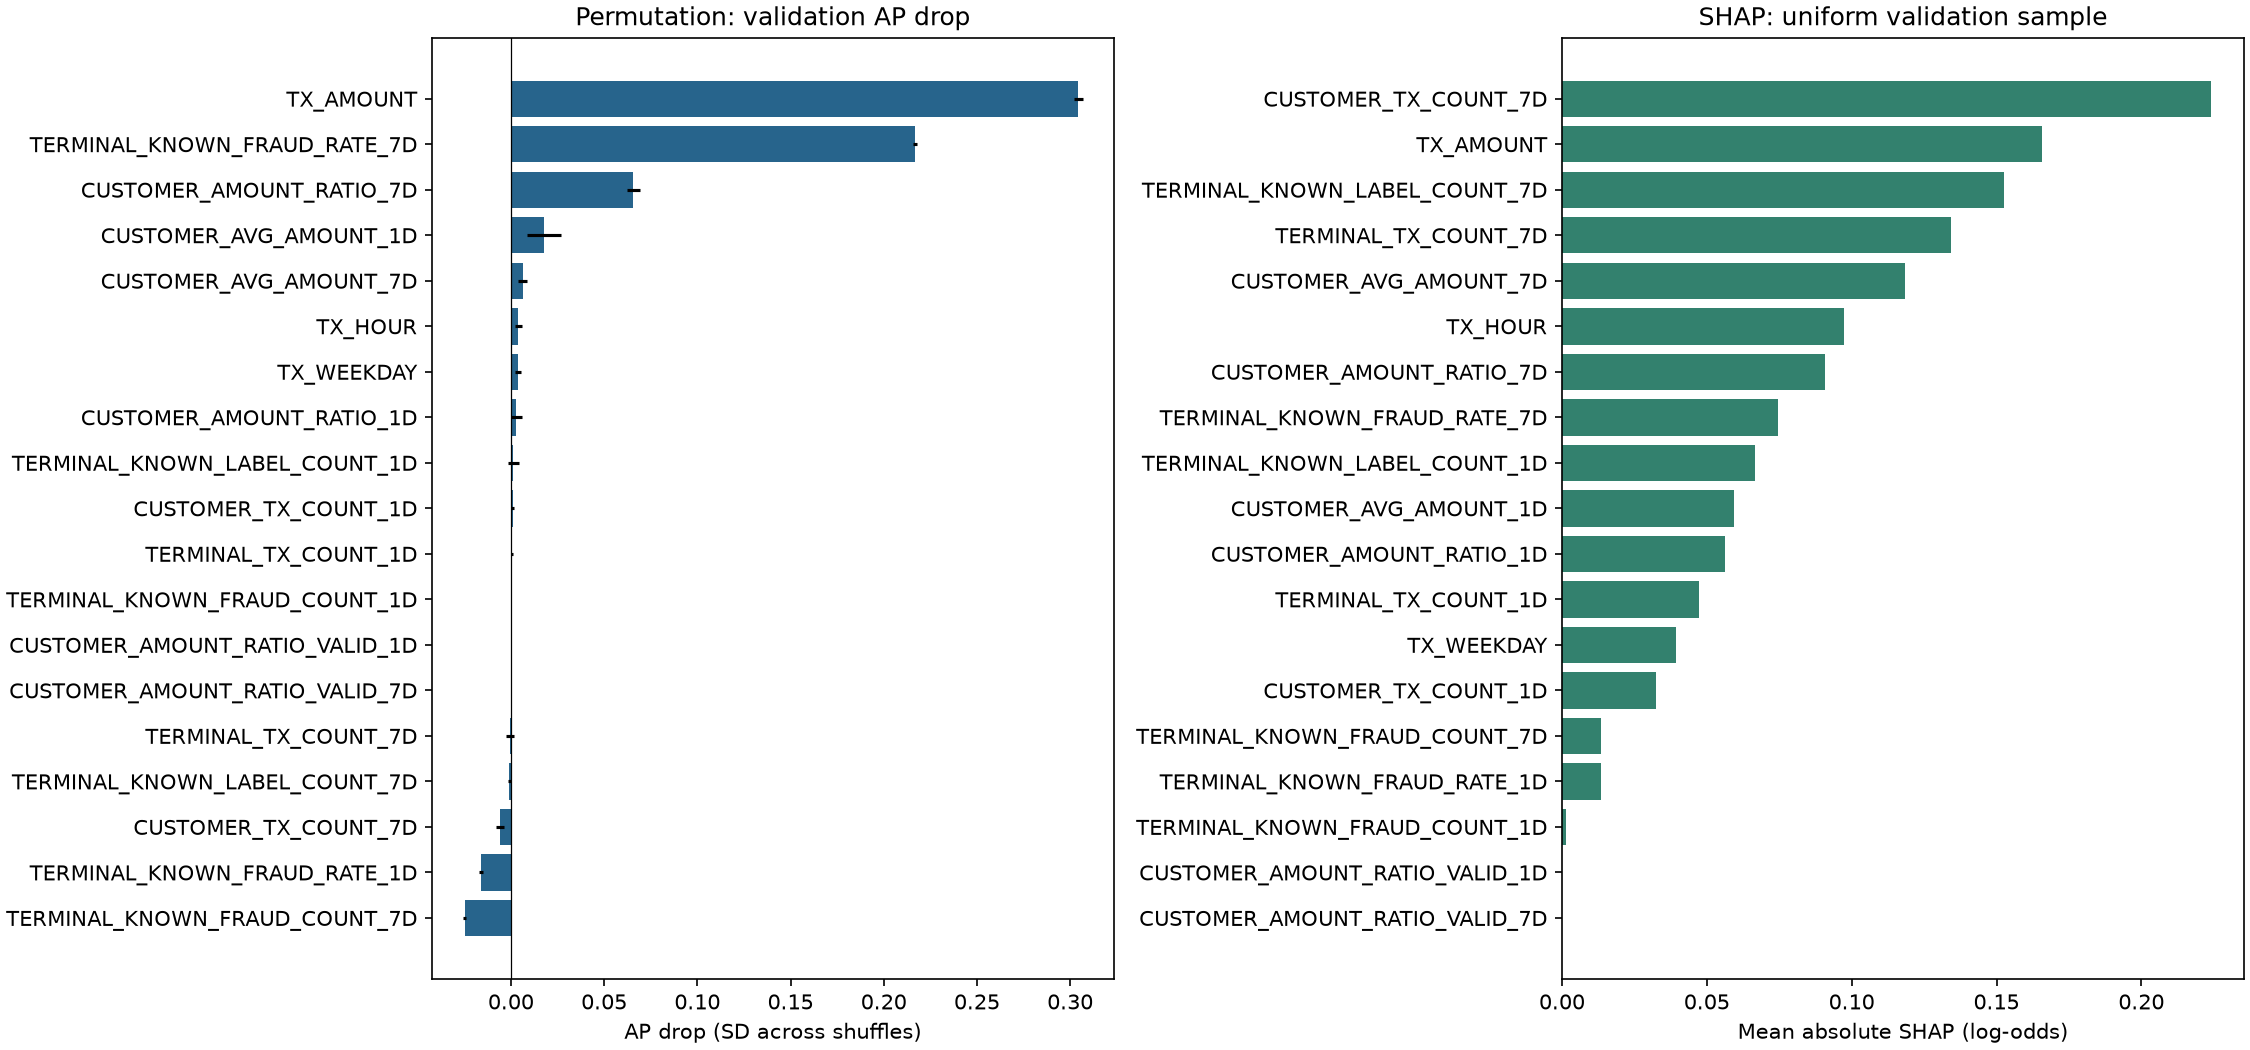

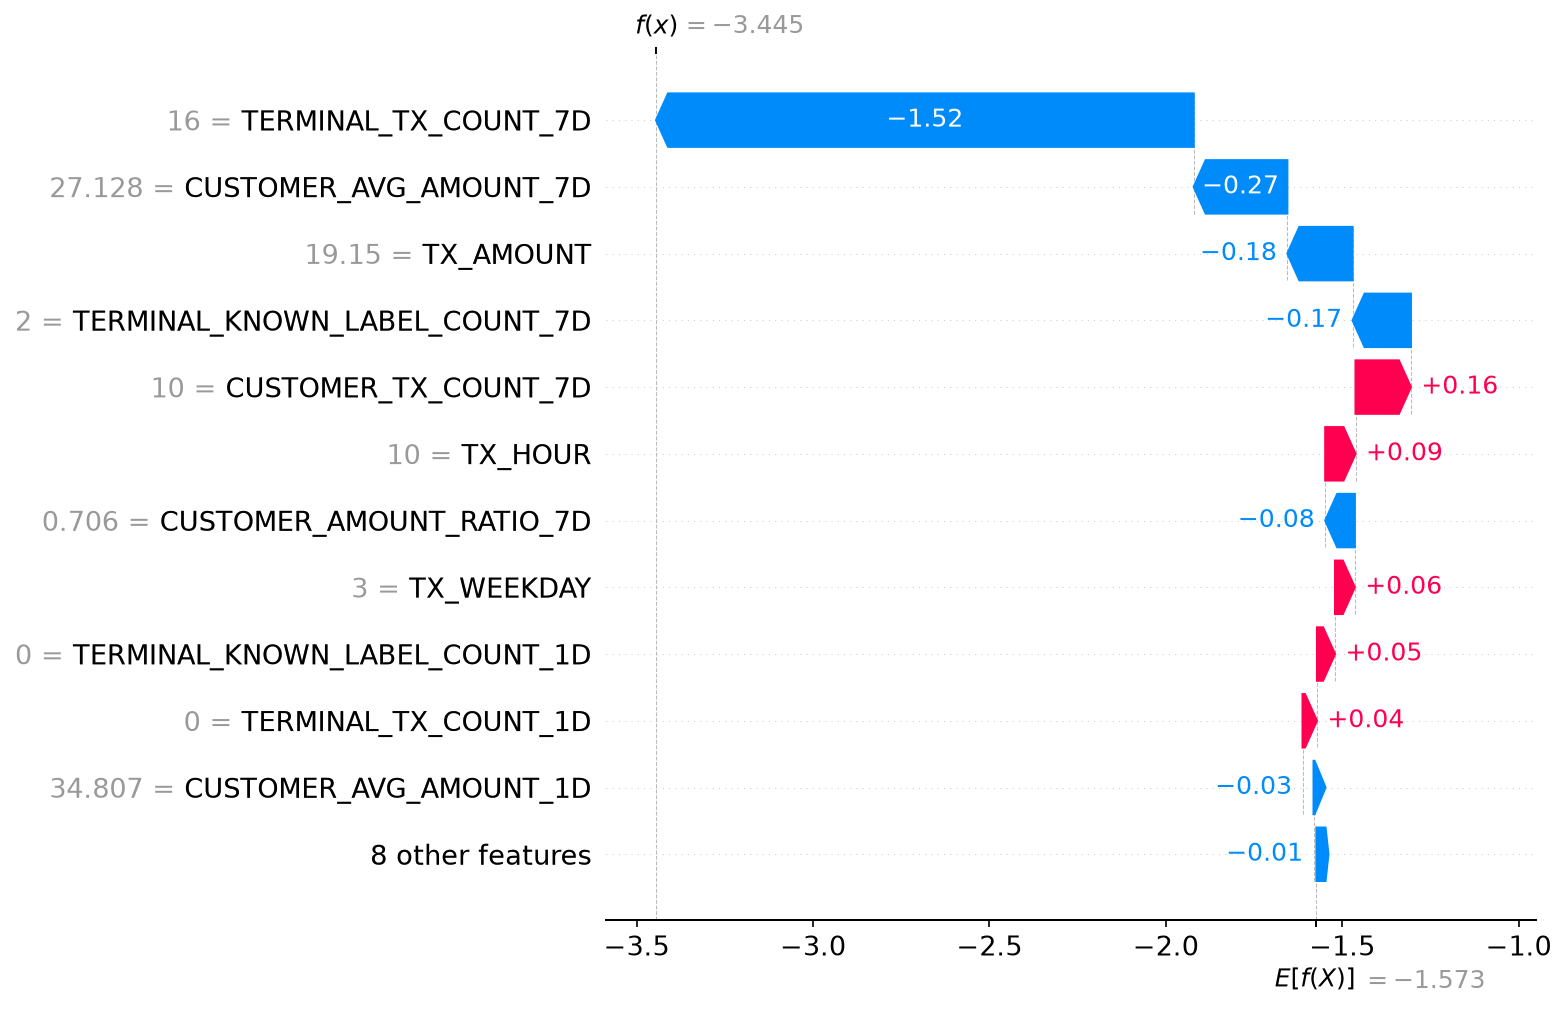

In [4]:
from IPython.display import Image, display

display(Image(filename=str(run_dir / "importance.png")))
display(Image(filename=str(run_dir / "case_lowest_scored_fraud.png")))

## Interpretação da execução e dos gráficos — 2026-10-08

O relatório impresso confirma 67.255 transações e 580 fraudes na validação,
cinco repetições de permutação, mil exemplos uniformes SHAP e três casos adicionais
(total de 1.003 linhas explicadas). AP conjunta: 0,6239485132514692. O tempo
registrado de 5,89 s é uma observação local, não um benchmark de produção.

### Resultado operacional

Nos sete dias, HGB priorizou 378 ocorrências fraudulentas de cliente/dia,
contra 336 da regressão, em 700 posições de alerta para cada candidato.
O HGB deixou 133 ocorrências fraudulentas fora dos alertas, contra 175 da regressão.
São 42 ocorrências adicionais priorizadas, com clientes possivelmente repetidos
entre dias. Não são pessoas únicas ou perdas evitadas. A política usa o dia completo;
features causais não transformam esse ranking retrospectivo em uma fila online.

### Importância global: perguntas diferentes

A permutação por AP aponta maior dependência de `TX_AMOUNT` (queda 0,304394),
`TERMINAL_KNOWN_FRAUD_RATE_7D` (0,216758) e `CUSTOMER_AMOUNT_RATIO_7D` (0,065655).
SHAP coloca `CUSTOMER_TX_COUNT_7D` no topo da média absoluta em log-odds (0,224147),
embora sua permutação aumente a AP (queda de −0,005847).

O primeiro painel mede mudança de desempenho do ranking do modelo congelado;
o segundo resume contribuição ao score na amostra uniforme. Escalas, populações
e perguntas são diferentes. O desvio entre embaralhamentos não é intervalo de
confiança. Importância negativa não justifica remoção automática de features.

### Waterfall da fraude com menor score

A figura mostra `f(x) ≈ −3,445` e valor base `E[f(X)] ≈ −1,573`, em log-odds.
Aplicando a logística ao valor final arredondado, o score é aproximadamente
0,0309. Não foi demonstrada calibração; esse número não estabelece uma chance
real de fraude de 3,09%.

A contribuição negativa dominante é `TERMINAL_TX_COUNT_7D = 16` (cerca de −1,52).
Também reduzem o score `CUSTOMER_AVG_AMOUNT_7D = 27,128` (−0,27),
`TX_AMOUNT = 19,15` (−0,18) e `TERMINAL_KNOWN_LABEL_COUNT_7D = 2` (−0,17).
A razão entre valor e média de sete dias é aproximadamente 0,706: o valor está
abaixo desse histórico, e a razão contribui cerca de −0,08 no caso.
As contagens/valores são dados do caso; as contribuições descrevem o modelo
ajustado, não relações causais nem regras gerais sobre frequência e risco.

Há uma distinção útil: `TERMINAL_TX_COUNT_7D` tem queda global de AP próxima de
zero (−0,000437), mas domina a redução do score deste evento. Uma média global
não substitui a análise de casos. É preciso verificar se esse padrão se repete.
O gráfico não informa o cenário gerador, a posição diária do cliente ou os scores
de suas demais transações. Portanto, não demonstra que esse cliente ficou fora
dos cem alertas. Não usamos um limiar de 0,5 para concluir que ele foi perdido.

### Hipóteses para o próximo protocolo

- Investigar se o modelo depende de padrões de volume do terminal que reduzem
  scores de fraudes em certos grupos. Conferir recorrência por dia e por cenário
  de auditoria; um caso extremo não confirma um problema sistemático.
- Planejar uma ablação coerente de features de volume/suporte, com retreinamento
  e comparação pareada, mantendo explícitas as relações com as taxas de fraude.
- Fixar efeito relevante, orçamento e quality gates antes dos novos experimentos.
  Tratar dependência por dias/clientes e a limitação de apenas sete dias de validação.

Nenhuma feature foi removida. Não há tuning, teste de hipótese executado ou avaliação
do teste final nesta revisão. Outputs e células de código permanecem preservados.

Referências de interpretação: [scikit-learn: permutação](https://scikit-learn.org/stable/modules/permutation_importance.html)
e [SHAP: TreeExplainer](https://shap.readthedocs.io/en/latest/generated/shap.TreeExplainer.html).
